In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

In [5]:
iris_sns = sns.load_dataset('iris')
iris = load_iris()

In [6]:
X = iris.data
y = iris.target

In [7]:
feature_names = ['Sepal length,x1','Sepal width,x2',
                 'Petal length,x3','Petal width x4']

In [8]:
X_df = pd.DataFrame(X,columns = feature_names)

In [9]:
sns.set_style('ticks')

In [10]:
X = X_df.to_numpy()

Text(0.5, 1.0, 'X')

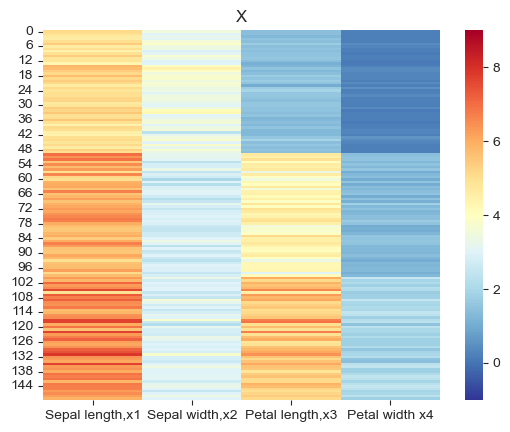

In [12]:
fig,ax = plt.subplots()
ax = sns.heatmap(X,
                 cmap = 'RdYlBu_r',
                 xticklabels = list(X_df.columns),
                 cbar_kws = {'orientation':'vertical'},
                 vmin = -1,vmax = 9)
plt.title('X')

In [13]:
v_1 = np.ones((len(X),1))
E_X = v_1.T @ X / len(X)

In [16]:
X_demean = X_df.sub(X_df.mean())#mean默认axis = 0,sub减法自动广播对齐

Text(0.5, 1.0, '$X_{demean}$')

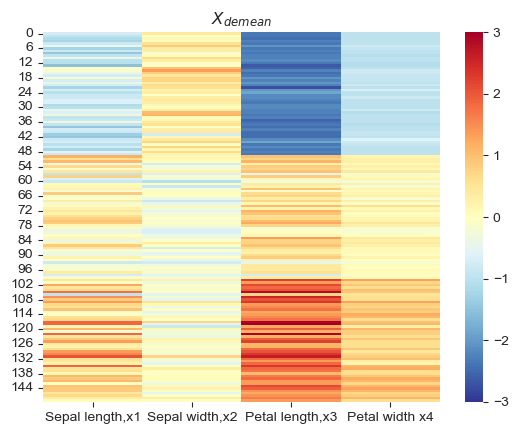

In [15]:
fig,ax = plt.subplots()
ax = sns.heatmap(X_demean,
                 cmap = 'RdYlBu_r',
                 xticklabels = list(X_df.columns),
                 cbar_kws = {'orientation':'vertical'},
                 vmin = -3,vmax = 3)
plt.title('$X_{demean}$')

In [18]:
SIGMA = X_df.cov()

In [32]:
SIGMA_inv = pd.DataFrame(data = np.linalg.inv(SIGMA.to_numpy()),columns = SIGMA.columns)

In [33]:
SIGMA_inv

,"Sepal length,x1","Sepal width,x2","Petal length,x3",Petal width x4
0,10.314699,-6.713189,-7.314483,5.739951
1,-6.713189,11.058417,6.480589,-6.170932
2,-7.314483,6.480589,10.031679,-14.513767
3,5.739951,-6.170932,-14.513767,27.693635


In [35]:
X_stand = X_demean.to_numpy() @ SIGMA_inv.to_numpy()

Text(0.5, 1.0, '$X_{stand}$')

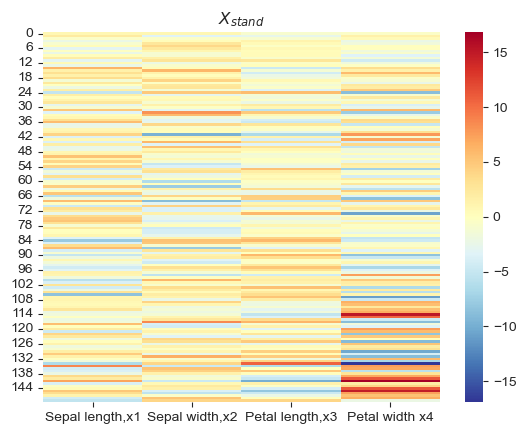

In [37]:
fig,ax = plt.subplots()
ax = sns.heatmap(X_stand,
                 cmap = 'RdYlBu_r',
                 xticklabels = list(X_df.columns),
                 cbar_kws = {'orientation':'vertical'})
plt.title('$X_{stand}$')